In [1]:
# Container-Informationen
!echo "===== Container ID ====="
!echo "Container ID: $(hostname)"

===== Container ID =====
Container ID: codespaces-2aaea0


In [2]:
# Betriebssystem
!echo "===== OS Release ====="
!cat /etc/os-release

===== OS Release =====
PRETTY_NAME="Ubuntu 24.04.2 LTS"
NAME="Ubuntu"
VERSION_ID="24.04"
VERSION="24.04.2 LTS (Noble Numbat)"
VERSION_CODENAME=noble
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=noble
LOGO=ubuntu-logo


In [3]:
# Aktueller Nutzer
!printf "\n===== Whoami =====\n"
!whoami


===== Whoami =====
jovyan


In [4]:
# uv-Version
!printf "\n===== uv Version =====\n"
!uv --version


===== uv Version =====
uv 0.6.6


In [5]:
# pyflyby-Version
!printf "\n===== pyflyby Version =====\n"
!python -c "import pyflyby; print(pyflyby.__version__)"


===== pyflyby Version =====
1.9.11


In [6]:
# Paket-Versionen in Dockerfile-Reihenfolge anzeigen
pakete = [
    "marimo", "jupyter-marimo-proxy", "jupyterlab-pyflyby", "pyflyby",
    "altair", "hvplot", "matplotlib", "memray", "numba", "numpy",
    "pandas", "plotly", "polars", "pyarrow", "scalene", "scipy", "viztracer"
]

print("===== Paketversionen =====\n")
import importlib.metadata

for paket in pakete:
    try:
        version = importlib.metadata.version(paket)
        print(f"{paket:<22} {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{paket:<22} (nicht installiert)")

===== Paketversionen =====

marimo                 0.11.20
jupyter-marimo-proxy   0.0.4
jupyterlab-pyflyby     5.1.2
pyflyby                1.9.11
altair                 5.5.0
hvplot                 0.11.2
matplotlib             3.10.1
memray                 1.16.0
numba                  0.61.0
numpy                  2.1.3
pandas                 2.2.3
plotly                 6.0.0
polars                 1.25.2
pyarrow                19.0.1
scalene                1.5.51
scipy                  1.15.2
viztracer              1.0.3


### Ausschnitt aus Dockerfile zum Vergleich
```Dockerfile
...
  uv pip install \
    # jupyterlab is preinstalled in the base image
    # jupyterlab==4.3.6 \
    # alternative to jupyter notebooks
    marimo==0.11.20 \
    # start marimo notebooks from jupyterlab
    jupyter-marimo-proxy==0.0.4 \
    # try to automatically import missing imports
    jupyterlab-pyflyby==5.1.2 \
    pyflyby==1.9.11 \
    # visualization
    altair==5.5.0 \
    # visualization
    hvplot==0.11.2 \
    # visualization
    matplotlib==3.10.1 \
    # memary profiler (tracer)
    memray==1.16.0 \
    # just-in-time compiler for numerical functions
    numba==0.61.0 \
    # arrays, version set by numba
    numpy \
    # dataframes
    pandas==2.2.3 \
    # visualization
    plotly==6.0.0 \
    # dataframes
    polars==1.25.2 \
    # polars backend, only used for to_pandas() when plotting with hvplot
    pyarrow==19.0.1 \
    # CPU, GPU, and memory profiler (sampler)
    scalene==1.5.51 \
    # algorithms for scientific computing
    scipy==1.15.2 \
    # python tracer
    viztracer==1.0.3 && \
  # load pyflyby automatically
  py pyflyby.install_in_ipython_config_file
  ...

In [7]:
# Import-Test
print("===== Import-Test =====")

for pkg in [
    "marimo", "jupyter_marimo_proxy", "jupyterlab_pyflyby", "pyflyby",
    "altair", "hvplot", "matplotlib", "memray", "numba", "numpy",
    "pandas", "plotly", "polars", "pyarrow", "scalene", "scipy", "viztracer"
]:
    try:
        # Dynamischer Import: lädt ein Modul anhand seines Namens als String
        # Wenn __import__ benutzt wird, muss man das geladene Modul explizit einer Variablen zuweisen
        # Hier wird es nur für die Überprüfung verwendet
        __import__(pkg) 
        print(f"{pkg} kann ohne Probleme importiert werden")
    except ImportError:
        print(f"{pkg} ACHTUNG: PAKET KANN NICHT IMPORTIERT WERDEN")

===== Import-Test =====
marimo kann ohne Probleme importiert werden
jupyter_marimo_proxy kann ohne Probleme importiert werden
jupyterlab_pyflyby kann ohne Probleme importiert werden
pyflyby kann ohne Probleme importiert werden
altair kann ohne Probleme importiert werden
hvplot kann ohne Probleme importiert werden
matplotlib kann ohne Probleme importiert werden
memray kann ohne Probleme importiert werden
numba kann ohne Probleme importiert werden
numpy kann ohne Probleme importiert werden
pandas kann ohne Probleme importiert werden
plotly kann ohne Probleme importiert werden
polars kann ohne Probleme importiert werden
pyarrow kann ohne Probleme importiert werden
scalene kann ohne Probleme importiert werden
scipy kann ohne Probleme importiert werden
viztracer kann ohne Probleme importiert werden


In [8]:
import numpy as np              # Für numerische Operationen und Arrays
import matplotlib.pyplot as plt # Für grafische Darstellung der Ergebnisse

# Projektarbeit: Die Differentialgleichung der Biegelinie

**Autor:** Ahmed Hossam
**Zeitraum:** Juni–August 2025  
**Thema:** Analyse und numerische Lösung der Biegelinien-Differentialgleichung für elastische Balken

---

## Einleitung

In dieser Projektarbeit befasse ich mich mit der mathematischen Modellierung und Lösung der sogenannten *Biegelinien-Differentialgleichung*, die das Durchbiegeverhalten elastischer Balken beschreibt. Diese Gleichung ist zentraler Bestandteil der Technischen Mechanik und findet vielfältige Anwendungen in der Statik und im Maschinenbau.

Die Untersuchung umfasst:

- die **Herleitung** der Differentialgleichung der Biegelinie aus physikalischen Grundlagen,
- die **analytische Lösung einfacher Szenarien** (z. B. Balken mit Einzellast oder gleichmäßig verteilter Last),
- die **numerische Lösung komplexerer Fälle** mithilfe moderner Pythonpakete (z. B. `scipy`),
- sowie eine **grafische Darstellung** der Ergebnisse zur Veranschaulichung des Biegeverhaltens (z. B. , `matplotlib`).

Ziel der Arbeit ist es, sowohl das physikalisch-mathematische Verständnis als auch die praktische Umsetzung numerischer Lösungsverfahren zur Biegelinie zu vertiefen.

---

## Physikalische Grundlagen

Die Biegelinie beschreibt die Durchbiegung eines Balkens in Abhängigkeit von der Position entlang seiner Längsachse. Die Form des Balkens wird durch die Wirkung äußerer Kräfte und Momente beeinflusst.

Grundlage ist die sogenannte **Euler-Bernoulli-Balkentheorie**, die auf folgenden Annahmen basiert:

- Der Balken ist schlank (Länge ≫ Querschnitt).
- Querschnitte bleiben nach der Biegung eben und normal zur neutralen Faser.
- Es treten keine Schubverformungen auf.

Die zentrale physikalische Größe zur Beschreibung der Biegung ist das **Biegemoment** $M(x)$, das über die Krümmung der Biegelinie mit dem Elastizitätsmodul $E$ und dem Flächenträgheitsmoment $I$ des Balkens verknüpft ist:

$$
M(x) = -EI \cdot \frac{d^2 w(x)}{dx^2}
$$

Dabei ist:

- $w(x)$: die Auslenkung des Balkens an der Stelle $x$,
- $E$: Elastizitätsmodul des Materials,
- $I$: Flächenträgheitsmoment des Balkenquerschnitts.

Die Krümmung der Biegelinie ist also proportional zum Biegemoment.

---

Auf Basis der vorgestellten physikalischen Zusammenhänge ergibt sich für die Biegelinie $w(x)$ eine Differentialgleichung vierter Ordnung. Im nächsten Schritt wenden wir uns der numerischen Lösung dieser Gleichung zu, da analytische Lösungen nur in einfachen Fällen existieren oder sehr aufwendig sind.


## Numerische Lösung der Biegelinien-Differentialgleichung

Das Ziel dieses Abschnitts ist es, die Differentialgleichung der Biegelinie numerisch zu lösen. Dazu verwenden wir die Finite-Differenzen-Methode (FDM), eine bewährte Technik zur Approximation von Differentialgleichungen durch diskrete Differenzenquotienten.

Die Differentialgleichung zweiter Ordnung für die Auslenkung $w(x)$ eines Balkens unter Belastung lautet allgemein:

$$
EI \frac{d^4 w}{dx^4} = q(x)
$$

wobei $q(x)$ die verteilte Last ist.

Wir diskretisieren den Balken in $N$ gleich große Abschnitte und approximieren die Ableitungen durch Differenzenquotienten. So entsteht ein lineares Gleichungssystem der Form:

$$
\mathbf{A} \mathbf{w} = \mathbf{b}
$$

Im Folgenden implementieren wir Schritt für Schritt die Diskretisierung, den Aufbau der Matrix $\mathbf{A}$ und die Lösung des Systems.


### Herleitung der Finite-Differenzen-Diskretisierung für die vierte Ableitung

Um die Differentialgleichung der Biegelinie numerisch zu lösen, approximieren wir die Ableitungen durch endliche Differenzen auf einem diskreten Gitter.

**Diskretisierung des Balkens**  
Wir teilen den Balken der Länge $L$ in $N$ gleich große Abschnitte auf, sodass wir die Stützstellen  
$$
x_0, x_1, \ldots, x_N
$$  
mit Abstand  
$$
h = \frac{L}{N}
$$  
erhalten. Die Auslenkung an diesen Punkten schreiben wir als $w_i = w(x_i)$.


### Herleitung der Finite-Differenzen-Approximation für die vierte Ableitung

Finite Differenzen basieren auf der Taylorentwicklung einer Funktion $w$ um einen Punkt $x$. Allgemein gilt für ein kleines $h$ und eine beliebige Verschiebung $m \in \mathbb{Z}$:

$$
w(x + m h) = \sum_{k=0}^\infty \frac{w^{(k)}(x)}{k!} m^k h^k
$$

Das bedeutet, der Funktionswert an $x + m h$ lässt sich als unendliche Summe von Ableitungen an $x$ multipliziert mit Potenzen von $m h$ ausdrücken.

Um eine numerische Approximation der vierten Ableitung $w^{(4)}(x)$ zu erhalten, betrachten wir die Taylorreihen von $w$ an den benachbarten Punkten $x \pm h$ und $x \pm 2h$:

$$
\begin{aligned}
w(x + h) &= w(x) + h w'(x) + \frac{h^2}{2} w''(x) + \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + O(h^5) \\
w(x - h) &= w(x) - h w'(x) + \frac{h^2}{2} w''(x) - \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + O(h^5) \\
w(x + 2h) &= w(x) + 2h w'(x) + 2 h^2 w''(x) + \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + O(h^5) \\
w(x - 2h) &= w(x) - 2h w'(x) + 2 h^2 w''(x) - \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + O(h^5)
\end{aligned}
$$

**Jetzt setzen wir diese Taylorreihen in eine allgemeine Linearkombination ein:**  

$$
a \cdot w(x - 2h) + b \cdot w(x - h) + c \cdot w(x) + d \cdot w(x + h) + e \cdot w(x + 2h)
$$

Dabei ersetzen wir jeden Term durch seine Taylor-Entwicklung um $x$:

$$
\begin{aligned}
& a \left[ w(x) - 2h w'(x) + 2 h^2 w''(x) - \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + \ldots \right] \\
+& b \left[ w(x) - h w'(x) + \frac{h^2}{2} w''(x) - \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + \ldots \right] \\
+& c \cdot w(x) \\
+& d \left[ w(x) + h w'(x) + \frac{h^2}{2} w''(x) + \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + \ldots \right] \\
+& e \left[ w(x) + 2h w'(x) + 2 h^2 w''(x) + \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + \ldots \right]
\end{aligned}
$$

Nun fassen wir alle Terme zusammen, indem wir nach den Ableitungen von $w$ an der Stelle $x$ gruppieren:

$$
\begin{aligned}
& (a + b + c + d + e) \cdot w(x) \\
+& (-2a - b + d + 2e) \cdot h w'(x) \\
+& \left( 2a + \frac{b}{2} + \frac{d}{2} + 2e \right) \cdot h^2 w''(x) \\
+& \left( -\frac{4}{3} a - \frac{b}{6} + \frac{d}{6} + \frac{4}{3} e \right) \cdot h^3 w^{(3)}(x) \\
+& \left( \frac{2}{3} a + \frac{b}{24} + \frac{d}{24} + \frac{2}{3} e \right) \cdot h^4 w^{(4)}(x) + \ldots
\end{aligned}
$$

Unser Ziel ist, alle Terme außer dem mit $w^{(4)}(x)$ zu eliminieren, also die Koeffizienten der Terme mit $w(x)$, $w'(x)$, $w''(x)$ und $w^{(3)}(x)$ auf null zu setzen. Dadurch erhalten wir eine Approximation für die vierte Ableitung:

$$
\begin{cases}
a + b + c + d + e = 0 \\
-2a - b + d + 2e = 0 \\
2a + \frac{b}{2} + \frac{d}{2} + 2e = 0 \\
-\frac{4}{3} a - \frac{b}{6} + \frac{d}{6} + \frac{4}{3} e = 0 \\
\frac{2}{3} a + \frac{b}{24} + \frac{d}{24} + \frac{2}{3} e = K \neq 0
\end{cases}
$$

Die Lösung lautet:

$$
a = 1, \quad b = -4, \quad c = 6, \quad d = -4, \quad e = 1, \quad K = 1
$$

Damit erhalten wir die finite Differenzen-Formel für die vierte Ableitung:

$$
w^{(4)}(x) \approx \frac{w(x - 2h) - 4 w(x - h) + 6 w(x) - 4 w(x + h) + w(x + 2h)}{h^4} + O(h^2)
$$

Diese Formel verwendet fünf symmetrisch um $x$ verteilte Punkte und ist genau bis zur Ordnung $O(h^2)$.

---

Mit diesem Verfahren lassen sich Differentialgleichungen mit vierter Ableitung diskretisieren und numerisch lösen.



**Schritt: Finite-Differenzen-Approximation der vierten Ableitung**  
Für die vierte Ableitung $\frac{d^4 w}{dx^4}$ an einem inneren Gitterpunkt $x_i$ (mit $2 \leq i \leq N-2$) gilt folgende zentrale Differenzenformel (Genauigkeit $O(h^2)$):

$$
\frac{d^4 w}{dx^4}\bigg|_{x_i} \approx \frac{w_{i-2} - 4 w_{i-1} + 6 w_i - 4 w_{i+1} + w_{i+2}}{h^4}
$$

Diese Formel bezieht die Auslenkungen an fünf benachbarten Punkten mit ein.


**Behandlung der Randpunkte und Ghost Points**  
An den Randpunkten ($i = 0, 1, N-1, N$) ist die direkte Anwendung der obigen Differenzenformel **nicht möglich**, da sie Werte außerhalb des Gitters erfordert (z. B. $w_{-1}$ oder $w_{N+2}$). Solche hypothetischen Punkte werden als *Ghost Points* bezeichnet.

Um dennoch ein geschlossenes Gleichungssystem zu erhalten, werden die Ghost Points durch geeignete Umformung mithilfe der vorgegebenen **Randbedingungen** ersetzt. Typische Randbedingungen (z. B. feste Einspannung, gelenkiges oder freies Lager) liefern Gleichungen, aus denen sich diese Ghost-Werte eliminieren oder durch bekannte Größen ausdrücken lassen.

Alternativ können für die Randpunkte spezielle Differenzenschemata niedrigerer Ordnung oder modifizierte Gleichungen verwendet werden, die direkt die jeweilige Randbedingung abbilden.

**Aufbau eines linearen Gleichungssystems**  
Für jeden inneren Punkt setzen wir die Differentialgleichung

$$
EI \frac{d^4 w}{dx^4} = q(x)
$$

ein und ersetzen die Ableitung durch die finite Differenz:

$$
EI \cdot \frac{w_{i-2} - 4 w_{i-1} + 6 w_i - 4 w_{i+1} + w_{i+2}}{h^4} = q_i
$$

Für alle inneren Punkte zusammen erhalten wir ein lineares Gleichungssystem der Form

$$
EI \mathbf{A} \mathbf{w} = \mathbf{q}
$$

wobei

- $\mathbf{w} = [w_0, w_1, \ldots, w_N]^T$ der Vektor der Auslenkungen an den Gitterpunkten ist,  
- $\mathbf{q} = [q_0, q_1, \ldots, q_N]^T$ die Werte der verteilten Last an den Punkten enthält,  
- und $\mathbf{A}$ eine sogenannte **pentadiagonale Matrix** ist, die die Koeffizienten der Finite-Differenzen enthält und an den Rändern durch die Randbedingungen angepasst wird.

---

Mit diesem Verständnis können wir nun konkret die Matrix $\mathbf{A}$ aufbauen und das Gleichungssystem numerisch lösen.

In [9]:
# -----------------------------------------------
# Vorbereitung: Parameterdefinition und Diskretisierung
# -----------------------------------------------
# In diesem Abschnitt definieren wir die physikalischen Eigenschaften des Balkens
# sowie die numerischen Parameter für die Finite-Differenzen-Methode (FDM).
# Anschließend diskretisieren wir das Balkensegment in gleichmäßige Abschnitte.
# Ziel ist es, ein Gitter mit Stützstellen x_0, x_1, ..., x_N aufzubauen
# und an diesen Punkten die Biegelinie zu berechnen.
# -----------------------------------------------

# --- Physikalische Parameter ---
L = 1.0      # Länge des Balkens in Metern (m)
EI = 1.0     # Biegesteifigkeit: Produkt aus Elastizitätsmodul E und Flächenträgheitsmoment I

# --- Numerische Diskretisierung ---
N = 100      # Anzahl der Unterteilungen des Balkens (Anzahl Gitterintervalle)
h = L / N    # Schrittweite h = Abstand zwischen zwei benachbarten Gitterpunkten

# --- Erzeugung der Gitterpunkte ---
x = np.linspace(0, L, N + 1)  # np.linspace erzeugt N+1 gleichmäßig verteilte Punkte von 0 bis L
                              # Diese entsprechen den Knotenpunkten x_0, x_1, ..., x_N

# --- Lastverteilung ---
q = np.ones_like(x)  # Erzeugt ein Array mit denselben Dimensionen wie x, gefüllt mit Einsen
                     # Entspricht einer konstanten, gleichmäßig verteilten Last q(x) = 1 auf dem gesamten Balken
                     # Vorteil: q bleibt automatisch synchron mit der Diskretisierung von x (robuster und wartbarer)


## Aufbau der Biegesteifigkeitsmatrix $A$ mittels Finiter Differenzen

Zur Lösung der Biegungsgleichung eines schlanken Balkens

$$
EI \cdot w^{(4)}(x) = q(x)
$$

wird die Ableitung vierter Ordnung durch ein zentrales Finite-Differenzen-Schema approximiert. Dies führt auf ein lineares Gleichungssystem der Form

$$
A \cdot \vec{w} = \vec{q}
$$

wobei $\vec{w}$ der Vektor der gesuchten Verschiebungen an diskreten Gitterpunkten $x_0, x_1, \dots, x_{N-1}$ ist und $\vec{q}$ die diskretisierte Lastfunktion darstellt.

### Diskretisierung der vierten Ableitung

Für die inneren Knotenpunkte $i = 2, \dots, N-3$ wird die vierte Ableitung durch die sogenannte 5-Punkt-Formel ersetzt:

$$
w^{(4)}(x_i) \approx \frac{w_{i-2} - 4w_{i-1} + 6w_i - 4w_{i+1} + w_{i+2}}{h^4}
$$

Daraus ergibt sich für diese Knoten die folgende Struktur der Matrix $A$:

- Hauptdiagonale: $6$
- Nebendiagonalen: $-4$ (links und rechts daneben)
- Zwei Diagonalen weiter außen: $1$ (links und rechts)

Diese Koeffizienten werden mit $\frac{EI}{h^4}$ skaliert.


### Behandlung der Randbedingungen

Die äußeren Zeilen der Matrix $A$ (also Zeilen $0$, $1$, $N-3$, $N-2$, $N-1$) werden abhängig von der Randlagerung modifiziert, um bestimmte physikalische Randbedingungen zu erzwingen. Folgende Typen sind implementiert:

| Randbedingung           | Linkes Ende                       | Rechtes Ende                      | Kommentar zur Randbedingung                        |
|------------------------|----------------------------------|----------------------------------|---------------------------------------------------|
| **beidseitig gelenkig**| $w(0) = 0$ <br> $w''(0) = 0$    | $w(L) = 0$ <br> $w''(L) = 0$    | Beide Enden sind gelenkig gelagert <br> (keine Verschiebung, kein Moment) |
| **nur links eingespannt** | $w(0) = 0$ <br> $w'(0) = 0$    | $w''(L) = 0$ <br> $w'''(L) = 0$ | Links feste Einspannung <br> (keine Verschiebung und Rotation), <br> rechts frei (kein Moment, keine Scherkraft) |
| **nur rechts eingespannt**| $w''(0) = 0$ <br> $w'''(0) = 0$ | $w(L) = 0$ <br> $w'(L) = 0$    | Rechts feste Einspannung, <br> links frei <br> (Moment- und Scherkraftfreiheit) |

---

### Finite-Differenzen-Approximationen: zentral, vorwärts und rückwärts

Finite-Differenzen sind numerische Methoden, um Ableitungen anhand diskreter Werte einer Funktion $w_i = w(x_i)$ zu approximieren. Dabei stehen verschiedene Arten von Differenzen zur Verfügung:

- **Vorwärtsdifferenz:**  
  Nutzt Werte an $x_i$ und den nächsten Punkten rechts davon (z.B. $x_{i+1}$, $x_{i+2}$).  
  Vorteil: Einfach am linken Rand anzuwenden, da Punkte rechts vorhanden sind.  
  Beispiel für erste Ableitung:  
  $w'(x_0) \approx \frac{w_1 - w_0}{h}$  
  (für höhere Genauigkeit gibt es auch erweiterte Formeln, siehe unten)

- **Rückwärtsdifferenz:**  
  Nutzt Werte an $x_i$ und Punkten links davon (z.B. $x_{i-1}$, $x_{i-2}$).  
  Vorteil: Gut am rechten Rand anwendbar, wenn keine Werte rechts verfügbar sind.  
  Beispiel für erste Ableitung:  
  $w'(x_{N-1}) \approx \frac{w_{N-1} - w_{N-2}}{h}$

- **Zentrale Differenz:**  
  Nutzt Werte symmetrisch links und rechts von $x_i$ (z.B. $x_{i-1}$ und $x_{i+1}$).  
  Vorteil: Höhere Genauigkeit, da symmetrisch.  
  Beispiel für zweite Ableitung:  
  $w''(x_i) \approx \frac{w_{i-1} - 2 w_i + w_{i+1}}{h^2}$

---

### Herleitungen der Finite-Differenzen-Randbedingungen

Die folgenden Randbedingungen wurden mit Hilfe der Taylorreihenentwicklung der Funktion $w(x)$ an den Rändern des Balkens hergeleitet. Für Ableitungen werden Vorwärts- und Rückwärtsdifferenzen verwendet, je nachdem, ob man sich am linken oder rechten Rand befindet. Der Gitterabstand sei konstant mit $h$.

---


## Fall 1: Beidseitig gelenkig gelagert  
**Randbedingungen:**
- Linkes Ende: $w(0) = 0$, $w''(0) = 0$
- Rechtes Ende: $w(L) = 0$, $w''(L) = 0$

### Herleitung von $w(0) = 0$  
Dies ist eine Dirichlet-Randbedingung:  
Der Funktionswert ist am linken Rand direkt bekannt.  
$\Rightarrow w_0 = 0$

### Herleitung von $w''(0) = 0$ (Vorwärtsdifferenz 2. Ordnung)

Entwickle $w(x)$ an den Punkten $x_1 = h$ und $x_2 = 2h$ um $x_0 = 0$:

- $w_1 = w_0 + h w_0' + \frac{h^2}{2} w_0'' + \frac{h^3}{6} w_0''' + \dots$
- $w_2 = w_0 + 2h w_0' + 2h^2 w_0'' + \frac{4h^3}{3} w_0''' + \dots$

Subtrahiere $2 \cdot$ (erste Gleichung) von der zweiten:

- $w_2 - 2 w_1 + w_0 = h^2 w_0'' + \mathcal{O}(h^3)$

$\Rightarrow w''(0) \approx \frac{w_0 - 2 w_1 + w_2}{h^2} = 0$

### Herleitung von $w(L) = 0$  
Ebenfalls Dirichlet-Bedingung:  
$\Rightarrow w_{N-1} = 0$

### Herleitung von $w''(L) = 0$ (Rückwärtsdifferenz 2. Ordnung)

Entwickle um $x_{N-1}$ rückwärts:

- $w_{N-2} = w_{N-1} - h w_{N-1}' + \frac{h^2}{2} w_{N-1}'' - \frac{h^3}{6} w_{N-1}''' + \dots$
- $w_{N-3} = w_{N-1} - 2h w_{N-1}' + 2h^2 w_{N-1}'' - \frac{4h^3}{3} w_{N-1}''' + \dots$

Ergibt:

- $w_{N-1} - 2 w_{N-2} + w_{N-3} = h^2 w_{N-1}'' + \mathcal{O}(h^3)$

$\Rightarrow w''(L) \approx \frac{w_{N-1} - 2 w_{N-2} + w_{N-3}}{h^2} = 0$

---


## Fall 2: Nur links eingespannt  
**Randbedingungen:**
- Linkes Ende: $w(0) = 0$, $w'(0) = 0$
- Rechtes Ende: $w''(L) = 0$, $w'''(L) = 0$

### Herleitung von $w(0) = 0$  
Dirichlet-Randbedingung:  
$\Rightarrow w_0 = 0$

### Herleitung von $w'(0) = 0$ (Vorwärtsdifferenz 2. Ordnung)

Entwickle:

- $w_1 = w_0 + h w_0' + \frac{h^2}{2} w_0'' + \dots$
- $w_2 = w_0 + 2h w_0' + 2h^2 w_0'' + \dots$

Linearkombination:

- $-3 w_0 + 4 w_1 - w_2 = 2h w_0' + \mathcal{O}(h^3)$

$\Rightarrow w'(0) \approx \frac{-3 w_0 + 4 w_1 - w_2}{2h} = 0$

### Herleitung von $w''(L) = 0$ (Rückwärtsdifferenz)

Wie oben:

$\Rightarrow w''(L) \approx \frac{w_{N-1} - 2 w_{N-2} + w_{N-3}}{h^2} = 0$

### Herleitung von $w'''(L) = 0$ (Rückwärtsdifferenz 3. Ordnung)

Entwickle rückwärts:

- $w_{N-4} = w_{N-1} - 3h w_{N-1}' + \frac{9h^2}{2} w_{N-1}'' - \frac{9h^3}{2} w_{N-1}''' + \dots$
- $w_{N-3} = w_{N-1} - 2h w_{N-1}' + 2h^2 w_{N-1}'' - \frac{4h^3}{3} w_{N-1}''' + \dots$
- $w_{N-2} = w_{N-1} - h w_{N-1}' + \frac{h^2}{2} w_{N-1}'' - \frac{h^3}{6} w_{N-1}''' + \dots$

Kombination:

- $-w_{N-4} + 3 w_{N-3} - 3 w_{N-2} + w_{N-1} = h^3 w_{N-1}''' + \mathcal{O}(h^4)$

$\Rightarrow w'''(L) \approx \frac{-w_{N-4} + 3 w_{N-3} - 3 w_{N-2} + w_{N-1}}{h^3} = 0$

---

## Fall 3: Nur rechts eingespannt  
**Randbedingungen:**
- Linkes Ende: $w''(0) = 0$, $w'''(0) = 0$
- Rechtes Ende: $w(L) = 0$, $w'(L) = 0$

### Herleitung von $w''(0) = 0$  
Wie in Fall 1:

$\Rightarrow w''(0) \approx \frac{w_0 - 2 w_1 + w_2}{h^2} = 0$

### Herleitung von $w'''(0) = 0$ (Vorwärtsdifferenz 3. Ordnung)

Entwickle:

- $w_1 = w_0 + h w_0' + \frac{h^2}{2} w_0'' + \frac{h^3}{6} w_0''' + \dots$
- $w_2 = w_0 + 2h w_0' + 2h^2 w_0'' + \frac{4h^3}{3} w_0''' + \dots$
- $w_3 = w_0 + 3h w_0' + \frac{9h^2}{2} w_0'' + \frac{9h^3}{2} w_0''' + \dots$

Kombination:

- $-w_0 + 3 w_1 - 3 w_2 + w_3 = h^3 w_0''' + \mathcal{O}(h^4)$

$\Rightarrow w'''(0) \approx \frac{-w_0 + 3 w_1 - 3 w_2 + w_3}{h^3} = 0$

### Herleitung von $w(L) = 0$  
Dirichlet:  
$\Rightarrow w_{N-1} = 0$

### Herleitung von $w'(L) = 0$ (Rückwärtsdifferenz 2. Ordnung)

Wie bei $w'(0)$, nur rückwärts:

- $w'(L) \approx \frac{3 w_{N-1} - 4 w_{N-2} + w_{N-3}}{2h} = 0$

---

### Finite-Differenzen-Approximationen

- **Erste Ableitung (vorwärts, links):**

  Für höhere Genauigkeit verwendet man oft die sogenannte 3-Punkt-Formel:

  $$
  w'(0) \approx \frac{-3 w_0 + 4 w_1 - w_2}{2 h} = 0
  $$

  Diese Formel ist zweite Ordnung genau (Fehler $\propto h^2$) und basiert auf der Taylor-Reihen-Subtraktion.

- **Erste Ableitung (rückwärts, rechts):**

  Entsprechend am rechten Rand:

  $$
  w'(L) \approx \frac{3 w_{N-1} - 4 w_{N-2} + w_{N-3}}{2 h} = 0
  $$

- **Zweite Ableitung (zentral):**

  Am Rand kann man die 3-Punkt-Formel verwenden:

  $$
  w''(0) \approx \frac{w_0 - 2 w_1 + w_2}{h^2} = 0
  $$

  Analog am rechten Rand:

  $$
  w''(L) \approx \frac{w_{N-3} - 2 w_{N-2} + w_{N-1}}{h^2} = 0
  $$

- **Dritte Ableitung (vorwärts, links):**

  Für die dritte Ableitung existiert auch eine 4-Punkt-Formel:

  $$
  w'''(0) \approx \frac{-w_0 + 3 w_1 - 3 w_2 + w_3}{h^3} = 0
  $$

- **Dritte Ableitung (rückwärts, rechts):**

  Entsprechend am rechten Rand:

  $$
  w'''(L) \approx \frac{-w_{N-4} + 2 w_{N-3} - 2 w_{N-2} + w_{N-1}}{2 h^3} = 0
  $$

---

Diese Formeln werden in die Randzeilen der Matrix $A$ eingesetzt, um die jeweiligen Randbedingungen direkt im linearen Gleichungssystem zu erzwingen.

### Ergebnis

Die Funktion `build_bending_matrix(...)` erzeugt eine $(N \times N)$-Matrix $A$, die das Differentialproblem

$$
EI \cdot w^{(4)}(x) = q(x)
$$

diskretisiert. Durch Lösen des Gleichungssystems

$$
A \vec{w} = \vec{q}
$$

kann die Biegelinie $\vec{w}$ numerisch berechnet werden.

In [15]:
def build_bending_matrix(N, h, EI, boundary_condition="beidseitig_gelenkig"):
    """
    Erzeugt die Biegesteifigkeitsmatrix A für einen Balken, die Diskretisierung
    der Gleichung EI * w'''' = q(x) mit der Finite-Differenzen-Methode.

    Parameter:
    - N: Anzahl der Gitterpunkte inkl. Rand (Index von 0 bis N-1)
    - h: Abstand zwischen den Gitterpunkten
    - EI: Biegesteifigkeit (konstant)
    - boundary_condition: Randbedingung als String, möglich:
        * "beidseitig_gelenkig": w=0 und w''=0 an beiden Enden
        * "nur_links_eingespannt": links w=0, w'=0; rechts w''=0, w'''=0
        * "nur_rechts_eingespannt": links w''=0, w'''=0; rechts w=0, w'=0

    Rückgabe:
    - A: (N x N)-Matrix zur Diskretisierung von EI * w'''' = q
    """

    if boundary_condition == "beidseitig_gelenkig" and N < 5:
        raise ValueError("Mindestens 5 Punkte für 'beidseitig_gelenkig' erforderlich!")
    elif "eingespannt" in boundary_condition and N < 6:
        raise ValueError("Mindestens 6 Punkte für eingespannten Rand erforderlich!")

    if EI <= 0:
        raise ValueError("EI muss größer oder gleich 0 sein!")

    A = np.zeros((N, N))

    # ===========================
    # 1. Diskretisierung im Inneren
    # ===========================
    # Für innere Punkte i=2 ... N-3 (weil wir 2 Nachbarn links und rechts brauchen)
    # Diskretisierung der 4. Ableitung mit Standard-Finite-Differenzen:
    # w''''(x_i) ≈ (w_{i-2} - 4 w_{i-1} + 6 w_i - 4 w_{i+1} + w_{i+2}) / h^4

    start_idx = 2
    end_idx = N - 2

    # Indexbereich der Matrix, der mit Finite-Differenzen beschrieben werden darf
    indices = np.arange(start_idx, end_idx)

    # Diskretisierung der 4. Ableitung
    A[indices, indices - 2] = 1 / h**4
    A[indices, indices - 1] = -4 / h**4
    A[indices, indices    ] = 6 / h**4
    A[indices, indices + 1] = -4 / h**4
    A[indices, indices + 2] = 1 / h**4

    # ===========================
    # 2. Randbedingungen
    # ===========================

    # Hier setzen wir die Randbedingungen direkt in der Matrix A um.
    # WICHTIG: Dies überschreibt die entsprechenden Zeilen in A,
    # um die Randwerte (Dirichlet oder Ableitungen) exakt vorzugeben.
    #
    # Dabei gilt: A @ w = q
    # - w ist der Vektor der Verschiebungen an den Gitterpunkten
    # - q ist der Vektor der äußeren Lasten (belastungsabhängig)
    #
    # Wenn z.B. w(0) = 0 vorgegeben ist, setzen wir die erste Zeile von A so,
    # dass nur w_0 darin auftaucht, und die rechte Seite q[0] muss dann auch 0 sein.
    # Somit erzwingen wir im Gleichungssystem w_0 = 0 unabhängig von der Last.
    #
    # Dadurch wird das lineare System korrekt gelöst, auch an den Rändern,
    # wo sonst Ableitungen auf Punkte außerhalb des Gitters zugreifen würden.

    if boundary_condition == "beidseitig_gelenkig": # A ist symmetrisch
    # --- Linke Randbedingung: w(0) = 0 ---
        # Wir wollen erzwingen, dass die Verschiebung (w) am linken Rand exakt 0 ist.
        # Das bedeutet: w_0 = 0, wobei w_0 die Verschiebung am ersten Gitterpunkt ist.
        #
        # Unser System ist A @ w = q, mit A als Matrix, w als Vektor der unbekannten Verschiebungen.
        #
        # Um im linearen Gleichungssystem w_0 = 0 sicherzustellen, stellen wir die erste Zeile so ein,
        # dass sie nur diese Variable betrifft:
        #    1 * w_0 + 0 * w_1 + 0 * w_2 + ... = 0
        #
        # In Matrixform: A[0,:] = [1, 0, 0, ..., 0] und rechte Seite q[0] = 0.
        #
        # Dadurch wird beim Lösen des Systems der Wert w_0 genau auf 0 gesetzt,
        # unabhängig von anderen Gleichungen.
        #
        # Ohne diese explizite Festlegung könnte das System versuchen,
        # w_0 anhand der Differentialgleichung zu bestimmen,
        # was an den Rändern ohne Stützpunkte „außerhalb“ des Bereichs nicht sinnvoll ist.
        #
        # Beispiel:
        #   Für ein System mit 3 Punkten wäre die erste Zeile der Matrix:
        #     [1, 0, 0]
        #   Die erste Gleichung: w_0 = 0
        #
        # w(0) = 0 (Verschiebung am linken Rand)
        # Matrixzeile wird zu: 1 * w_0 = 0
        A[0, :] = 0
        A[0, 0] = 1
        # Rechte Seite (q) an dieser Stelle muss 0 sein, um w_0=0 zu erzwingen

        # --- Linke Randbedingung: w''(0) = 0 ---
        # Zweite Ableitung an x=0 soll 0 sein.
        #
        # Die zweite Ableitung approximieren wir mit einer 3-Punkte-Formel, da
        # außerhalb des Bereichs keine Punkte liegen (keine negativen Indizes).
        #
        # Die Formel lautet:
        #   w''(x_0) ≈ (w_0 - 2*w_1 + w_2) / h²
        #
        # Diese Approximation ist zweite Ordnung genau und benutzt nur Punkte im Bereich.
        #
        # Die Gleichung lautet also:
        #   (w_0 - 2 w_1 + w_2) / h² = 0
        #
        # Das setzen wir in die zweite Zeile der Matrix ein:
        A[1, :] = 0
        A[1, 0] = 1 / h**2
        A[1, 1] = -2 / h**2
        A[1, 2] = 1 / h**2
        # rechte Seite q[1] muss ebenfalls 0 sein

    # --- Rechte Randbedingung: w(L) = 0 ---
        # Verschiebung am rechten Ende (x = L) soll exakt 0 sein.
        # Das heißt: w_{N-1} = 0, wobei N-1 der Index des letzten Gitterpunkts ist.
        #
        # Um das sicherzustellen, setzen wir die letzte Zeile der Matrix so,
        # dass nur die Variable w_{N-1} beteiligt ist:
        #    0 * w_0 + ... + 1 * w_{N-1} = 0
        #
        # Dadurch wird bei der Lösung w_{N-1} = 0 garantiert.
        #
        # Beispiel:
        #   Für ein System mit N=5 Gitterpunkten (Index 0..4) ist die letzte Zeile:
        #     [0, 0, 0, 0, 1]
        #   Die Gleichung: w_4 = 0
        A[-1, :] = 0
        A[-1, -1] = 1
        # (rechte Seite q[-1] muss 0 sein)

        # --- Rechte Randbedingung: w''(L) = 0 ---
        # Zweite Ableitung am rechten Rand soll 0 sein.
        #
        # Wir approximieren w''(x_{N-1}) mit der 3-Punkte-Rückwärts-Differenz,
        # weil rechts keine Gitterpunkte außerhalb des Bereichs existieren.
        #
        # Formel:
        #   w''(x_{N-1}) ≈ (w_{N-3} - 2 w_{N-2} + w_{N-1}) / h² = 0
        #
        # Damit fassen wir die letzte vorletzte Zeile zusammen:
        #
        # Beispiel für N=5:
        #   Index -3 entspricht 2, -2 entspricht 3, -1 entspricht 4
        #
        #   Die Zeile wird:
        #     0 * w_0 + ... + 1/h² * w_2 - 2/h² * w_3 + 1/h² * w_4 = 0
        #
        # Dies setzt die Krümmung (Biegung) am rechten Rand auf 0.
        A[-2, :] = 0
        A[-2, -3] = 1 / h**2
        A[-2, -2] = -2 / h**2
        A[-2, -1] = 1 / h**2
        # (rechte Seite q[-2] muss 0 sein)

    elif boundary_condition == "nur_links_eingespannt":
        # --- Linkes Ende: Eingespannt (feste Einspannung) ---
        # Bedingung: w(0) = 0, also keine Verschiebung am linken Ende
        A[0, :] = 0          # Alle Einträge in der ersten Zeile löschen
        A[0, 0] = 1          # Nur w_0 wird in der Gleichung verwendet: w_0 = 0
        q[0] = 0             # Rechte Seite q an dieser Stelle muss 0 sein (keine Verschiebung)

        # Bedingung: w'(0) = 0, also keine Rotation am linken Ende
        # Die erste Ableitung wird hier mit einer Vorwärts-Differenz approximiert:
        # w'(x_0) ≈ (-3 w_0 + 4 w_1 - w_2) / (2 h) = 0
        A[1, :] = 0          # Alle Einträge in der zweiten Zeile löschen
        A[1, 0] = -3 / (2*h)
        A[1, 1] =  4 / (2*h)
        A[1, 2] = -1 / (2*h)
        # q[1] sollte ebenfalls 0 sein, um w'(0)=0 zu erzwingen

        # --- Rechtes Ende: Frei (keine Momente, keine Scherkraft) ---
        # Bedingung: w''(L) = 0, Krümmung am rechten Ende soll null sein
        # Zweite Ableitung approximiert mit Rückwärts-Differenz:
        # w''(x_{N-1}) ≈ (w_{N-3} - 2 w_{N-2} + w_{N-1}) / h² = 0
        A[-2, :] = 0         # Vorletzte Zeile löschen
        A[-2, -3] =  1 / h**2
        A[-2, -2] = -2 / h**2
        A[-2, -1] =  1 / h**2
        # q[-2] ebenfalls 0 setzen

        # Bedingung: w'''(L) = 0, Scherkraft am rechten Ende soll null sein
        # Dritte Ableitung rückwärts differenziert (Rückwärts-Differenzformel):
        # w'''(x_{N-1}) ≈ (-w_{N-4} + 2 w_{N-3} - 2 w_{N-2} + w_{N-1}) / (2 h^3) = 0
        A[-1, :] = 0         # Letzte Zeile löschen
        A[-1, -4] = -1 / (2*h**3)
        A[-1, -3] =  2 / (2*h**3)
        A[-1, -2] = -2 / (2*h**3)
        A[-1, -1] =  1 / (2*h**3)
        # q[-1] ebenfalls 0 setzen


    elif boundary_condition == "nur_rechts_eingespannt":
        # --- Linkes Ende: Frei (keine Momente, keine Scherkraft) ---
        # Bedingung: w''(0) = 0, Krümmung am linken Ende soll null sein
        # Zweite Ableitung approximiert mit Vorwärts-Differenz:
        # w''(x_0) ≈ (w_0 - 2 w_1 + w_2) / h² = 0
        A[0, :] = 0          # Erste Zeile löschen
        A[0, 0] = 1 / h**2
        A[0, 1] = -2 / h**2
        A[0, 2] = 1 / h**2
        # q[0] auf 0 setzen

        # Bedingung: w'''(0) = 0, Scherkraft am linken Ende soll null sein
        # Dritte Ableitung vorwärts differenziert:
        # w'''(x_0) ≈ (-w_0 + 3 w_1 - 3 w_2 + w_3) / h³ = 0
        A[1, :] = 0          # Zweite Zeile löschen
        A[1, 0] = -1 / h**3
        A[1, 1] =  3 / h**3
        A[1, 2] = -3 / h**3
        A[1, 3] =  1 / h**3
        # q[1] auf 0 setzen

        # --- Rechtes Ende: Eingespannt (feste Einspannung) ---
        # Bedingung: w(L) = 0, keine Verschiebung am rechten Ende
        A[-2, :] = 0         # Vorletzte Zeile löschen
        A[-2, -1] = 1        # w_{N-1} = 0 direkt erzwingen
        # q[-2] = 0

        # Bedingung: w'(L) = 0, keine Rotation am rechten Ende
        # Erste Ableitung rückwärts differenziert:
        # w'(x_{N-1}) ≈ (3 w_{N-1} - 4 w_{N-2} + w_{N-3}) / (2 h) = 0
        A[-1, :] = 0         # Letzte Zeile löschen
        A[-1, -1] =  3 / (2*h)
        A[-1, -2] = -4 / (2*h)
        A[-1, -3] =  1 / (2*h)
        # q[-1] auf 0 setzen

    else:
        raise ValueError(f"Unbekannte Randbedingung: '{boundary_condition}'")

    return EI * A
# Hinweis:
# Die rechte Seite q muss an den Randstellen, wo Dirichlet- oder Ableitungsbedingungen
# vorgegeben sind, ebenfalls den passenden Wert enthalten (meist 0).

In [20]:
def plot_matrix_with_boundaries(A):
    n = A.shape[0]                  # Dimension der quadratischen Matrix
    n_rows = 10                    # Anzahl der Zeilen/Spalten für Randbedingungen

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 1x3 Subplots nebeneinander

    # Gesamtmatrix visualisieren: spy zeigt Nicht-Null-Elemente als Punkte
    axs[0].spy(A, markersize=1)   
    axs[0].set(title="Gesamtmatrix", xlabel="Spaltenindex", ylabel="Zeilenindex")
    axs[0].grid(True)              # Gitterlinien zur Orientierung

    # Obere linke Ecke (erste n_rows Zeilen/Spalten) als Randbedingung zoom
    axs[1].spy(A[:n_rows, :n_rows], markersize=5)
    axs[1].set(title=f"Obere Randbedingungen\n(erste {n_rows} Zeilen)",
               xlabel="Spaltenindex", ylabel="Zeilenindex",
               xticks=range(n_rows), yticks=range(n_rows))
    axs[1].grid(True)

    # Untere rechte Ecke (letzte n_rows Zeilen/Spalten) als Randbedingung zoom
    sub = A[-n_rows:, -n_rows:]
    axs[2].spy(sub, markersize=5)
    axs[2].set(title=f"Untere Randbedingungen\n(letzte {n_rows} Zeilen)",
               xlabel="Spaltenindex", ylabel="Zeilenindex",
               xticks=range(n_rows), yticks=range(n_rows),
               xticklabels=[str(i) for i in range(n - n_rows, n)],
               yticklabels=[str(i) for i in range(n - n_rows, n)])
    axs[2].grid(True)

    plt.tight_layout()   # Verhindert Überlappungen
    plt.show()           # Zeigt die Plots an

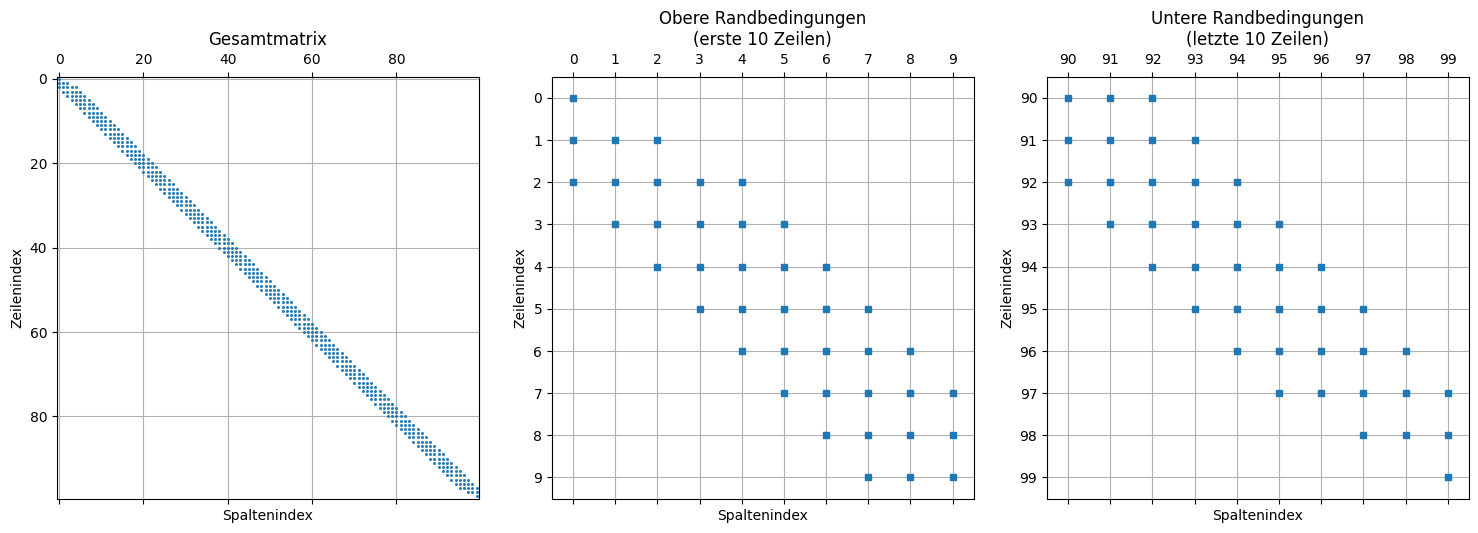

In [21]:
A1 = build_bending_matrix(N=100, h=0.01, EI=1.0, boundary_condition="beidseitig_gelenkig")
plot_matrix_with_boundaries(A1)


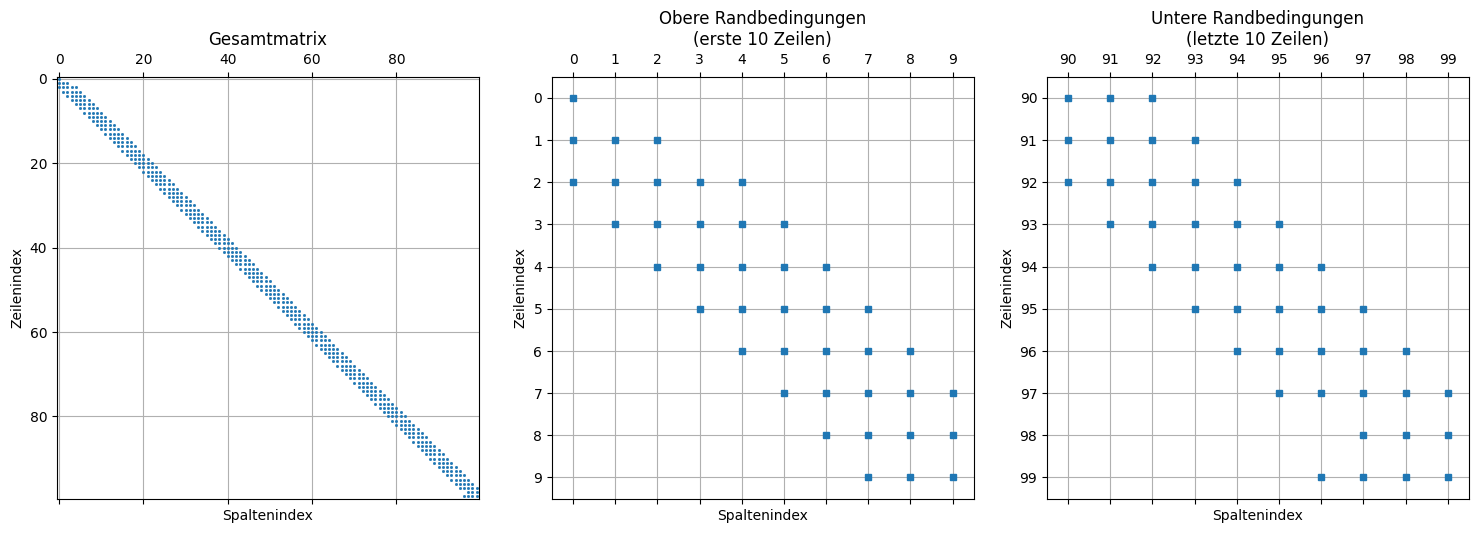

In [22]:
A2 = build_bending_matrix(N=100, h=0.01, EI=1.0, boundary_condition="nur_links_eingespannt")
plot_matrix_with_boundaries(A2)


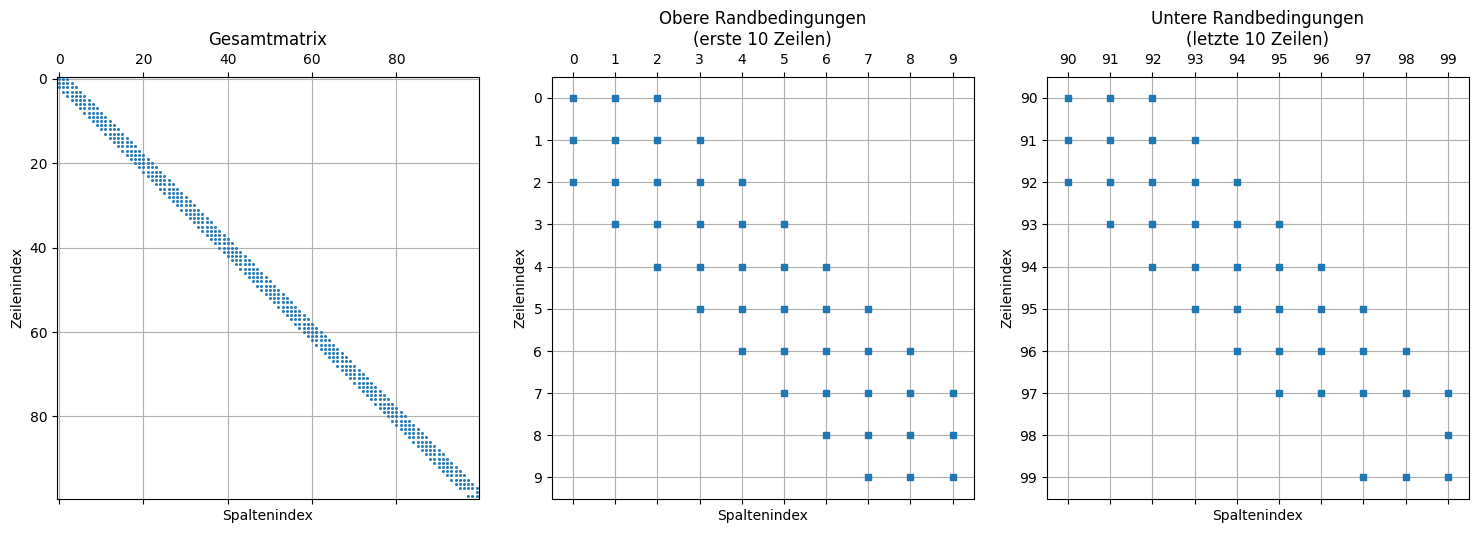

In [23]:
A3 = build_bending_matrix(N=100, h=0.01, EI=1.0, boundary_condition="nur_rechts_eingespannt")
plot_matrix_with_boundaries(A3)


## Matrixstruktur und Randbedingungen der Biegesteifigkeitsmatrix

Die Funktion `build_bending_matrix` erzeugt die Matrix $A$ für die Finite-Differenzen-Diskretisierung der Biegelinie-Gleichung  
$EI \cdot w'''' = q(x)$  
mit verschiedenen Randbedingungen.

---

### 1. `boundary_condition="beidseitig_gelenkig"`

- **Linkes Ende:**  
  $w(0) = 0$, $w''(0) = 0$
- **Rechtes Ende:**  
  $w(L) = 0$, $w''(L) = 0$
- **Matrix:**  
  - Die Randzeilen setzen die Verschiebung und Krümmung an beiden Enden exakt fest.
  - Die Matrix $A$ ist symmetrisch.
  - Die Finite-Differenzen-Schemata an den Rändern sind zweite Ordnung genau.
  
---

### 2. `boundary_condition="nur_links_eingespannt"`

- **Linkes Ende:**  
  $w(0) = 0$, $w'(0) = 0$
- **Rechtes Ende:**  
  $w''(L) = 0$, $w'''(L) = 0$
- **Matrix:**  
  - Links wird mit Vorwärts-Differenzen für $w'(0)$ gearbeitet.
  - Rechts wird mit Rückwärts-Differenzen für $w''(L)$ und $w'''(L)$ gearbeitet.
  - Matrix ist **nicht symmetrisch**.
  - Die Matrixstruktur spiegelt die einseitige Einspannung und das freie Ende wider.

---

### 3. `boundary_condition="nur_rechts_eingespannt"`

- **Linkes Ende:**  
  $w''(0) = 0$, $w'''(0) = 0$
- **Rechtes Ende:**  
  $w(L) = 0$, $w'(L) = 0$
- **Matrix:**  
  - Links wird mit Vorwärts-Differenzen für $w''(0)$ und $w'''(0)$ gearbeitet.
  - Rechts wird mit Rückwärts-Differenzen für $w'(L)$ gearbeitet.
  - Matrix ist **nicht symmetrisch**.
  - Die Struktur ist *physikalisch* Spiegelbild von Fall 2, aber **nicht exakt spiegelbildlich in der Matrixstruktur**,  
    da die Diskretierung der Randbedingungen unterschiedlich umgesetzt ist.

---

### Fazit zu den Unterschieden zwischen Fall 2 und Fall 3:
Obwohl die Randbedingungen physikalisch Spiegelbilder sind, führt die asymmetrische Approximation der Ableitungen (Vorwärts- vs. Rückwärts-Differenzen) dazu, dass die Matrizen $A_2$ und $A_3$ nicht exakt spiegelbildlich sind.

